## Signal definitions — update here when adding new inputs/outputs

In [120]:
INPUT_KEYS  = ['grf_x', 'grf_y', 'grf_z', 'cop_x', 'cop_y', 'cop_z']
# OUTPUT_KEYS = [
#     'achilles', 'addbrev', 'addlong', 'addmagDist', 'addmagIsch', 'addmagMid',
#     'addmagProx', 'bflh', 'bfsh', 'edl', 'ehl', 'fdl', 'fhl', 'gaslat',
#     'gasmed', 'glmax1', 'glmax2', 'glmax3', 'glmed1', 'glmed2', 'glmed3',
#     'glmin1', 'glmin2', 'glmin3', 'grac', 'iliacus', 'perbrev', 'perlong',
#     'psoas', 'recfem', 'semimem', 'semiten', 'soleus', 'tibant', 'tibpost',
#     'vasint', 'vaslat', 'vasmed',
# ]

OUTPUT_KEYS = ['achilles', 'addbrev', 'addlong', 'addmagDist', 'addmagIsch', 'addmagMid',
    'addmagProx', 'bflh', 'bfsh', 'edl', 'ehl', 'fdl', 'fhl', 'gaslat',
    'gasmed', 'glmax1', 'glmax2', 'glmax3', 'glmed1', 'glmed2', 'glmed3',
    'glmin1', 'glmin2', 'glmin3', 'grac', 'iliacus', 'perbrev', 'perlong',
    'psoas', 'recfem', 'semimem', 'semiten', 'soleus', 'tibant', 'tibpost',
    'vasint', 'vaslat', 'vasmed', 'knee_fx', 'knee_fy', 'knee_fz', 'ankle_fx', 'ankle_fy', 'ankle_fz'
]

# Optional: human-readable display names for plots/tables (must match ORDER of OUTPUT_KEYS)
# Set to None to fall back to OUTPUT_KEYS
OUTPUT_LABELS = None

N_INPUTS  = len(INPUT_KEYS)
N_OUTPUTS = len(OUTPUT_KEYS)

_labels = OUTPUT_LABELS if OUTPUT_LABELS is not None else OUTPUT_KEYS
assert len(_labels) == N_OUTPUTS, 'OUTPUT_LABELS length must match OUTPUT_KEYS'

print(f'Inputs  ({N_INPUTS}):  {INPUT_KEYS}')
print(f'Outputs ({N_OUTPUTS}): {OUTPUT_KEYS}')

Inputs  (6):  ['grf_x', 'grf_y', 'grf_z', 'cop_x', 'cop_y', 'cop_z']
Outputs (44): ['achilles', 'addbrev', 'addlong', 'addmagDist', 'addmagIsch', 'addmagMid', 'addmagProx', 'bflh', 'bfsh', 'edl', 'ehl', 'fdl', 'fhl', 'gaslat', 'gasmed', 'glmax1', 'glmax2', 'glmax3', 'glmed1', 'glmed2', 'glmed3', 'glmin1', 'glmin2', 'glmin3', 'grac', 'iliacus', 'perbrev', 'perlong', 'psoas', 'recfem', 'semimem', 'semiten', 'soleus', 'tibant', 'tibpost', 'vasint', 'vaslat', 'vasmed', 'knee_fx', 'knee_fy', 'knee_fz', 'ankle_fx', 'ankle_fy', 'ankle_fz']


## Config — set paths and models to compare here

In [128]:
data_dir      = 'C:\\Users\\bakel\\Desktop\\GRFMuscleModel\\Old_Young_Walking_Data\\'
model_dir     = '..\\models\\'
output_prefix = 'Silder_mixed_cop_leg_jrf'   # must match what Split_*_Dataset used
optuna_db     = f'sqlite:///{model_dir}optuna.db'

# Models to compare — each entry must have a matching <output_prefix>_<name>.pth
# and a corresponding Optuna study named <output_prefix>_<name> in the DB.
MODELS_TO_COMPARE = ['lstm', 'lstm_attn', 'cnn_lstm', 'transformer']

# Display names used in plots and tables (must align with MODELS_TO_COMPARE)
MODEL_LABELS = ['LSTM', 'LSTM+Attention', 'CNN-LSTM', 'Transformer']

# Plot colours (one per model)
MODEL_COLORS = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a']

# Which test sample to use for single-prediction plots
SAMPLE_IDX = 0

# Subset of outputs to evaluate / plot.
# Set to a list of names drawn from OUTPUT_KEYS, or None to use all outputs.
SUBSET_KEYS = ['tibpost', 'tibant', 'fdl', 'edl',
                'perbrev', 'perlong', 'achilles', 'ankle_fy', 'knee_fy' ]
# Example: SUBSET_KEYS = ['achilles', 'soleus', 'gaslat', 'gasmed', 'tibant', 'tibpost']

## Imports

In [129]:
import math
import numpy as np
import matplotlib.pyplot as plt
import optuna
import torch
import torch.nn as nn
from sklearn.metrics import r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Imports OK')

Imports OK


## Load test data

In [130]:
test_data = np.load(data_dir + f'{output_prefix}_test_data.npz')
X_test    = test_data['X_test']
y_test    = test_data['y_test']

assert X_test.shape[2] == N_INPUTS,  f'Expected {N_INPUTS} inputs,  got {X_test.shape[2]}'
assert y_test.shape[2] == N_OUTPUTS, f'Expected {N_OUTPUTS} outputs, got {y_test.shape[2]}'

SEQ_LEN = X_test.shape[1]
print(f'X_test: {X_test.shape}   y_test: {y_test.shape}')

X_test: (102, 100, 6)   y_test: (102, 100, 44)


## Device + tensors

In [131]:
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_test_t   = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t   = torch.tensor(y_test, dtype=torch.float32).to(device)
print(f'Device: {device}')

Device: cuda


## Model definitions

In [132]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out)


class LSTMAttentionModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_heads,
                 output_size, lstm_dropout=0.0, attn_dropout=0.0):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers,
                                 batch_first=True,
                                 dropout=lstm_dropout if num_layers > 1 else 0.0)
        self.attention = nn.MultiheadAttention(embed_dim=hidden_size,
                                               num_heads=num_heads,
                                               dropout=attn_dropout,
                                               batch_first=True)
        self.fc        = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        return self.fc(attn_out)


class CNNLSTMModel(nn.Module):
    def __init__(self, input_size, cnn_channels, hidden_size, num_layers,
                 output_size, dropout=0.0):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size,   cnn_channels,     kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(cnn_channels, cnn_channels * 2, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(cnn_channels * 2, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        cnn_out = self.cnn(x.permute(0, 2, 1))
        cnn_out = cnn_out.permute(0, 2, 1)
        lstm_out, _ = self.lstm(cnn_out)
        return self.fc(lstm_out)


class TransformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model, nhead,
                 num_encoder_layers, dim_feedforward, dropout):
        super().__init__()
        self.input_embedding = nn.Linear(input_dim, d_model)
        self.register_buffer('positional_encoding',
                             self._generate_positional_encoding(d_model, max_len=500))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer,
                                                          num_layers=num_encoder_layers)
        self.output_layer = nn.Linear(d_model, output_dim)

    def forward(self, x):
        seq_len = x.size(1)
        x = self.input_embedding(x)
        x = x + self.positional_encoding[:, :seq_len, :]
        x = self.transformer_encoder(x)
        return self.output_layer(x)

    @staticmethod
    def _generate_positional_encoding(d_model, max_len=500):
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             -(math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)


def build_model(model_name, bp):
    """Reconstruct a model from Optuna best_params (uses N_INPUTS / N_OUTPUTS from signal defs)."""
    if model_name == 'lstm':
        return LSTMModel(N_INPUTS, bp['hidden_size'], bp['num_layers'],
                         N_OUTPUTS, bp['dropout_rate']).to(device)
    elif model_name == 'lstm_attn':
        return LSTMAttentionModel(N_INPUTS, bp['hidden_size'], bp['num_layers'],
                                  bp['num_heads'], N_OUTPUTS,
                                  bp['lstm_dropout'], bp['attn_dropout']).to(device)
    elif model_name == 'cnn_lstm':
        return CNNLSTMModel(N_INPUTS, bp['cnn_channels'], bp['hidden_size'],
                            bp['num_layers'], N_OUTPUTS, bp['dropout_rate']).to(device)
    elif model_name == 'transformer':
        return TransformerModel(N_INPUTS, N_OUTPUTS,
                                bp['d_model'], bp['num_heads'],
                                bp['num_encoder_layers'],
                                bp['ff_mult'] * bp['d_model'],
                                bp['dropout_rate']).to(device)
    else:
        raise ValueError(f'Unknown model name: {model_name}')


print('Model classes and build_model defined.')

Model classes and build_model defined.


## Load models from weights

In [133]:
criterion    = nn.MSELoss()
test_results = {}   # {model_name: {'model': ..., 'preds': np.ndarray, 'test_loss': float}}

for model_name in MODELS_TO_COMPARE:
    weight_path = model_dir + f'{output_prefix}_{model_name}.pth'
    study_name  = f'{output_prefix}_{model_name}'
    print(study_name)
    try:
        study = optuna.load_study(study_name=study_name, storage=optuna_db)
        bp    = study.best_params
        model = build_model(model_name, bp)
        model.load_state_dict(torch.load(weight_path, map_location=device, weights_only=True))
        model.eval()

        with torch.no_grad():
            preds_t   = model(X_test_t)
            test_loss = criterion(preds_t, y_test_t).item()

        test_results[model_name] = {
            'model':     model,
            'preds':     preds_t.cpu().numpy(),
            'test_loss': test_loss,
        }
        print(f'{model_name:15s}  test_loss = {test_loss:.4f}')

    except Exception as e:
        print(f'Could not load {model_name}: {e}')

Silder_mixed_cop_leg_jrf_lstm
lstm             test_loss = 1.9664
Silder_mixed_cop_leg_jrf_lstm_attn
lstm_attn        test_loss = 2.0800
Silder_mixed_cop_leg_jrf_cnn_lstm
cnn_lstm         test_loss = 1.7911
Silder_mixed_cop_leg_jrf_transformer
transformer      test_loss = 1.8231


## Subset slicing — resolves SUBSET_KEYS into eval arrays

In [134]:
# Re-run this cell whenever you change SUBSET_KEYS or reload models.
if SUBSET_KEYS is None:
    _eval_idxs   = list(range(N_OUTPUTS))
    _eval_labels = list(_labels)
else:
    unknown = [k for k in SUBSET_KEYS if k not in OUTPUT_KEYS]
    assert not unknown, f'Unknown key(s) in SUBSET_KEYS: {unknown}'
    _eval_idxs   = [OUTPUT_KEYS.index(k) for k in SUBSET_KEYS]
    _eval_labels = [_labels[i] for i in _eval_idxs]

N_EVAL     = len(_eval_idxs)
y_eval     = y_test[:, :, _eval_idxs]                                          # (samples, seq_len, N_EVAL)
preds_eval = {n: r['preds'][:, :, _eval_idxs] for n, r in test_results.items()}

print(f'Evaluating {N_EVAL} output(s): {_eval_labels}')

Evaluating 9 output(s): ['tibpost', 'tibant', 'fdl', 'edl', 'perbrev', 'perlong', 'achilles', 'ankle_fy', 'knee_fy']


## Eval metric helpers
All functions operate on arrays shaped `(samples, seq_len, n_outputs)` and use
`OUTPUT_KEYS` / `_labels` for printing — no hard-coded signal names.

In [135]:
def _ranges(y):
    return y.max(axis=(0, 1)) - y.min(axis=(0, 1))   # (n_outputs,)


def calc_r2_per_output(y_true, y_pred, labels=None, verbose=True):
    ss_res = np.sum((y_true - y_pred) ** 2, axis=(0, 1))
    ss_tot = np.sum((y_true - np.mean(y_true, axis=(0, 1), keepdims=True)) ** 2, axis=(0, 1))
    r2 = 1 - ss_res / ss_tot
    if verbose:
        for lbl, v in zip(labels or _labels, r2):
            print(f'  {lbl}: {v:.4f}')
    return r2


def calc_r2_overall(y_true, y_pred):
    return r2_score(y_true.flatten(), y_pred.flatten())


def calc_rmse_per_output(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=(0, 1)))


def calc_rmse_overall(y_true, y_pred):
    return np.sqrt(np.mean((y_true.flatten() - y_pred.flatten()) ** 2))


def calc_rrmse_per_output(y_true, y_pred, labels=None, verbose=True):
    rrmse = calc_rmse_per_output(y_true, y_pred) / _ranges(y_true)
    if verbose:
        for lbl, v in zip(labels or _labels, rrmse):
            print(f'  {lbl}: {v:.4f}')
    return rrmse


def calc_rrmse_overall(y_true, y_pred):
    flat_t, flat_p = y_true.flatten(), y_pred.flatten()
    return np.sqrt(np.mean((flat_t - flat_p) ** 2)) / (flat_t.max() - flat_t.min())


def calc_rrmse_weighted(y_true, y_pred):
    r = _ranges(y_true)
    rrmse = calc_rmse_per_output(y_true, y_pred) / r
    return np.sum(rrmse * r) / np.sum(r)


def calc_rmspe_overall(y_true, y_pred):
    flat_t, flat_p = y_true.flatten(), y_pred.flatten()
    return np.sqrt(np.mean(((flat_t - flat_p) / flat_t) ** 2))


def calc_mae_per_output(y_true, y_pred, labels=None, verbose=True):
    mae = np.mean(np.abs(y_true - y_pred), axis=(0, 1))
    if verbose:
        for lbl, v in zip(labels or _labels, mae):
            print(f'  {lbl}: {v:.4f}')
    return mae


def calc_mae_overall(y_true, y_pred):
    return np.mean(np.abs(y_true.flatten() - y_pred.flatten()))




print('Metric helpers defined.')

Metric helpers defined.


## Per-output metrics

In [136]:
per_output = {}   # {model_name: {'rrmse': ..., 'mae': ..., 'r2': ...}}

for model_name, pred in preds_eval.items():
    print(f'\n=== {model_name} ===')
    print('-- RRMSE per output --')
    rrmse = calc_rrmse_per_output(y_eval, pred, labels=_eval_labels)
    print('-- MAE per output --')
    mae   = calc_mae_per_output(y_eval, pred, labels=_eval_labels)
    print('-- R² per output --')
    r2    = calc_r2_per_output(y_eval, pred, labels=_eval_labels)
    per_output[model_name] = {'rrmse': rrmse, 'mae': mae, 'r2': r2}


=== lstm ===
-- RRMSE per output --
  tibpost: 0.1412
  tibant: 0.1037
  fdl: 0.1788
  edl: 0.1289
  perbrev: 0.1269
  perlong: 0.1116
  achilles: 0.0626
  ankle_fy: 0.0582
  knee_fy: 0.0675
-- MAE per output --
  tibpost: 1.0568
  tibant: 0.6116
  fdl: 0.0740
  edl: 0.2417
  perbrev: 0.1473
  perlong: 0.4796
  achilles: 2.2136
  ankle_fy: 2.7912
  knee_fy: 2.9703
-- R² per output --
  tibpost: 0.3294
  tibant: 0.7026
  fdl: -0.0312
  edl: -0.1599
  perbrev: 0.6315
  perlong: 0.5280
  achilles: 0.9227
  ankle_fy: 0.9081
  knee_fy: 0.8439

=== lstm_attn ===
-- RRMSE per output --
  tibpost: 0.1306
  tibant: 0.1139
  fdl: 0.1721
  edl: 0.1107
  perbrev: 0.1244
  perlong: 0.0984
  achilles: 0.0685
  ankle_fy: 0.0631
  knee_fy: 0.0662
-- MAE per output --
  tibpost: 0.8929
  tibant: 0.6521
  fdl: 0.0723
  edl: 0.1751
  perbrev: 0.1441
  perlong: 0.4334
  achilles: 2.4049
  ankle_fy: 3.0330
  knee_fy: 2.8943
-- R² per output --
  tibpost: 0.4260
  tibant: 0.6410
  fdl: 0.0445
  edl: 0.1450

## Overall metrics summary

In [137]:
overall = {}   # {model_name: {metric_name: value}}

header = f'{"Model":<16}  {"MSE":>8}  {"RMSE":>8}  {"RRMSE":>8}  {"RRMSEw":>8}  {"RMSPE":>8}  {"MAE":>8}  {"R²":>8}'
print(header)
print('-' * len(header))

for model_name, pred in preds_eval.items():
    mse = nn.MSELoss()(
        torch.tensor(pred, dtype=torch.float32),
        torch.tensor(y_eval, dtype=torch.float32)
    ).item()
    m = {
        'mse':     mse,
        'rmse':    calc_rmse_overall(y_eval, pred),
        'rrmse':   calc_rrmse_overall(y_eval, pred),
        'rrmse_w': calc_rrmse_weighted(y_eval, pred),
        'rmspe':   calc_rmspe_overall(y_eval, pred),
        'mae':     calc_mae_overall(y_eval, pred),
        'r2':      calc_r2_overall(y_eval, pred),
    }
    overall[model_name] = m
    print(f'{model_name:<16}  {m["mse"]:>8.4f}  {m["rmse"]:>8.4f}  {m["rrmse"]:>8.4f}  '
          f'{m["rrmse_w"]:>8.4f}  {m["rmspe"]:>8.4f}  {m["mae"]:>8.4f}   {m["r2"]:>8.4f}')

Model                  MSE      RMSE     RRMSE    RRMSEw     RMSPE       MAE        R²
--------------------------------------------------------------------------------------
lstm                4.5215    2.1264    0.0185    0.0713    1.0669    1.1762     0.9783
lstm_attn           4.9019    2.2140    0.0193    0.0733    0.9533    1.1891     0.9764
cnn_lstm            4.2471    2.0608    0.0180    0.0685    0.9941    1.1226     0.9796
transformer         4.4339    2.1057    0.0184    0.0691    0.8481    1.1207     0.9787


## Visualization — mean ± SD across test set

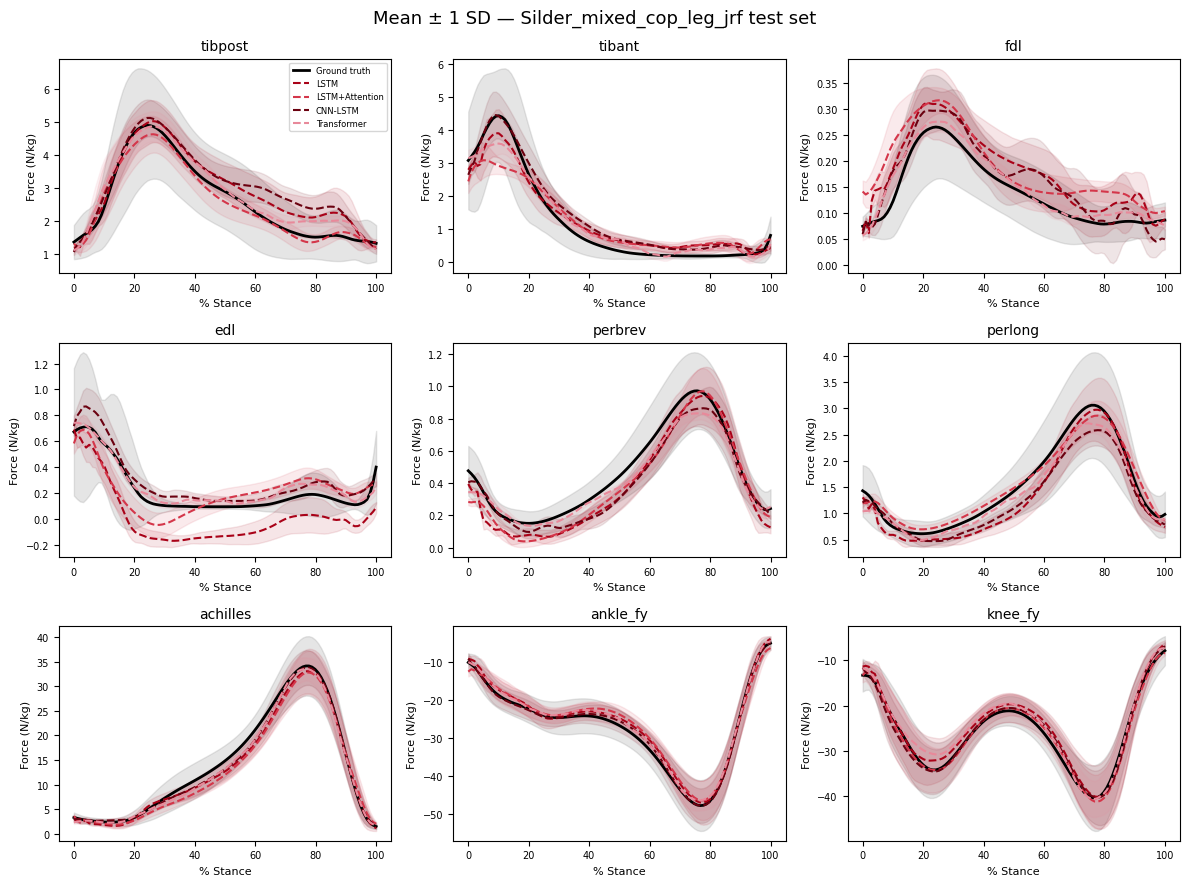

In [ ]:
MODEL_COLORS = ['#A90218', '#D4364A', '#6B0110', '#E8899A']
# dark crimson → mid red → maroon → dusty pink

MODEL_COLORS = ['#A90218', '#027A5E', '#D4364A', '#02A97E']
# crimson, dark teal, mid red, mid teal

MODEL_COLORS = ['#A90218', '#A97802', '#1852A9', '#6B0110']
# crimson, amber, steel blue, maroon



perc_stance = np.linspace(0, 100, SEQ_LEN)
true_mean   = y_eval.mean(axis=0)   # (seq_len, N_EVAL)
true_std    = y_eval.std(axis=0)

pred_means = {n: p.mean(axis=0) for n, p in preds_eval.items()}
pred_stds  = {n: p.std(axis=0)  for n, p in preds_eval.items()}

ncols = 3
nrows = math.ceil(N_EVAL / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for i, lbl in enumerate(_eval_labels):
    ax = axes[i]
    ax.plot(perc_stance, true_mean[:, i], color='black', linewidth=2, label='Ground truth')
    ax.fill_between(perc_stance,
                    true_mean[:, i] - true_std[:, i],
                    true_mean[:, i] + true_std[:, i],
                    color='gray', alpha=0.2)
    for model_name, label, color in zip(MODELS_TO_COMPARE, MODEL_LABELS, MODEL_COLORS):
        if model_name not in pred_means:
            continue
        ax.plot(perc_stance, pred_means[model_name][:, i],
                color=color, linewidth=1.5, linestyle='--', label=label)
        ax.fill_between(perc_stance,
                        pred_means[model_name][:, i] - pred_stds[model_name][:, i],
                        pred_means[model_name][:, i] + pred_stds[model_name][:, i],
                        color=color, alpha=0.1)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel('% Stance', fontsize=8)
    ax.set_ylabel('Force (N/kg)', fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=6)

for j in range(N_EVAL, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Mean ± 1 SD — {output_prefix} test set', fontsize=13)
plt.tight_layout()
plt.show()

## Visualization — individual mean ± SD plots (one per output)

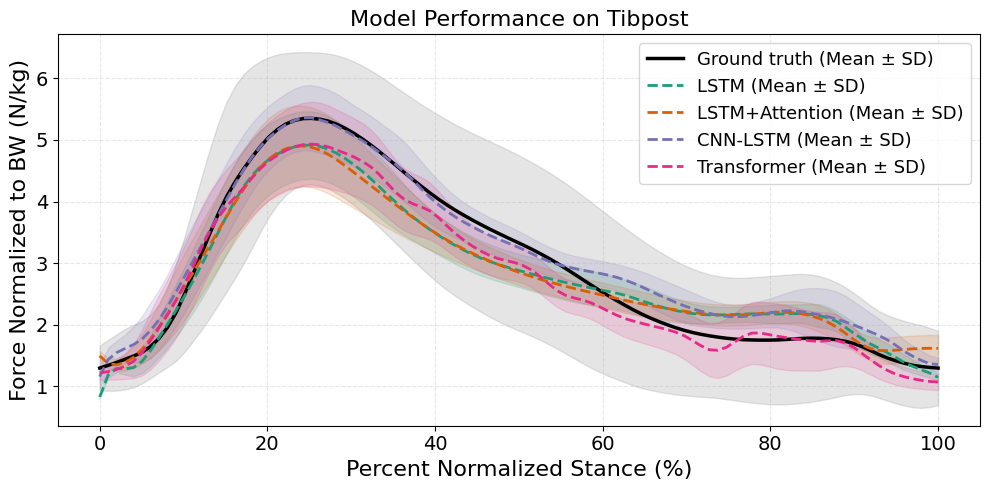

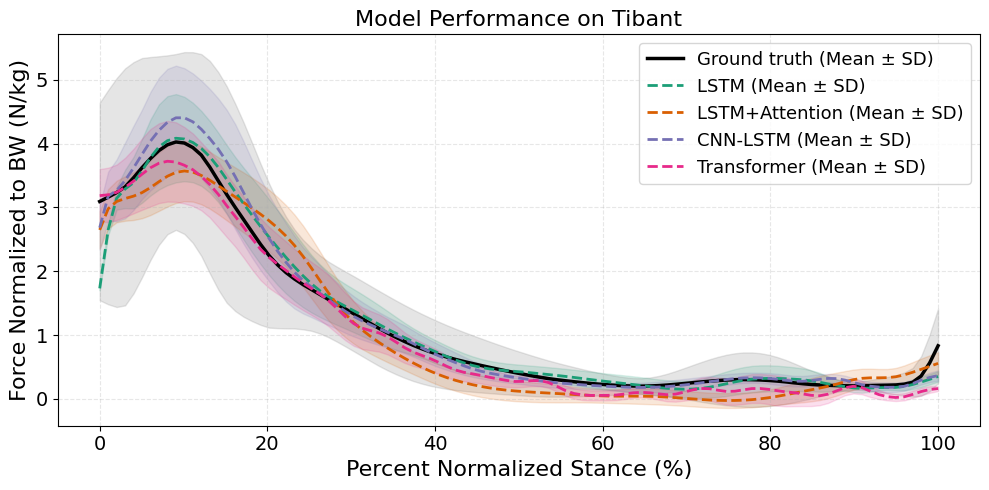

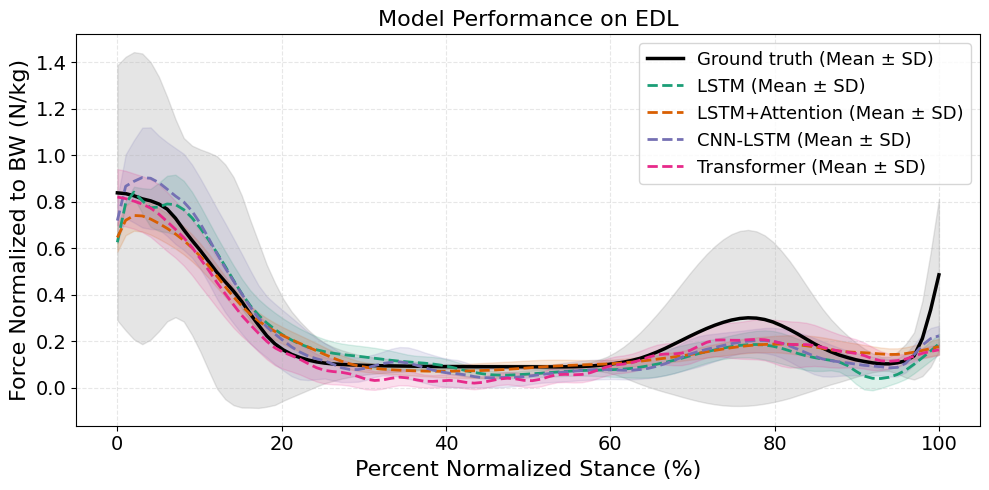

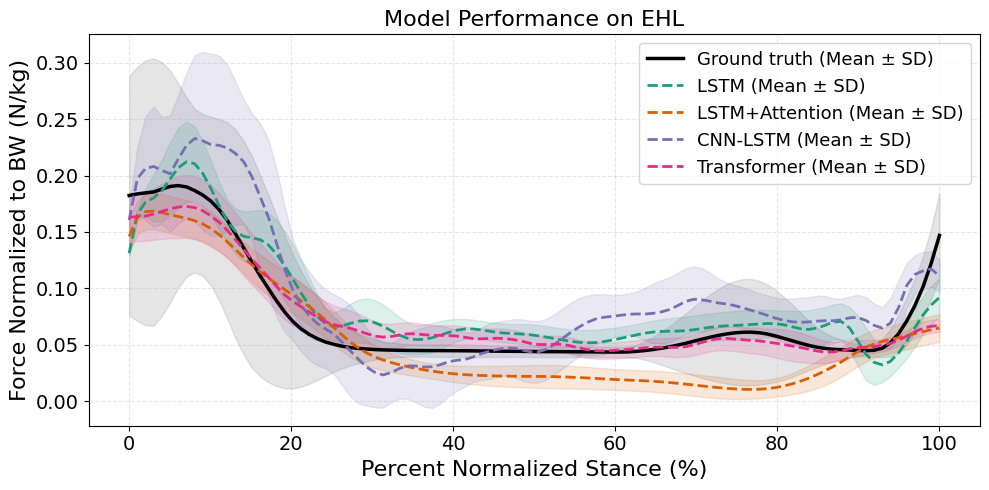

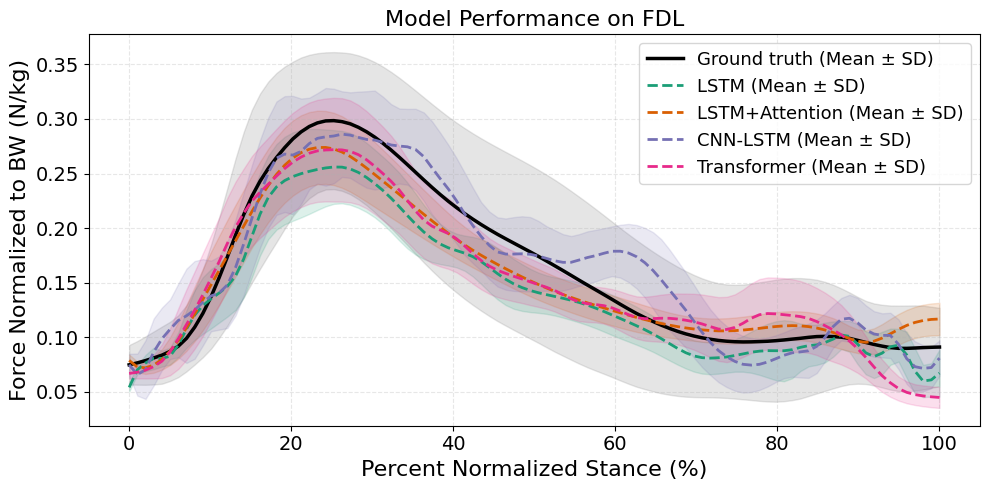

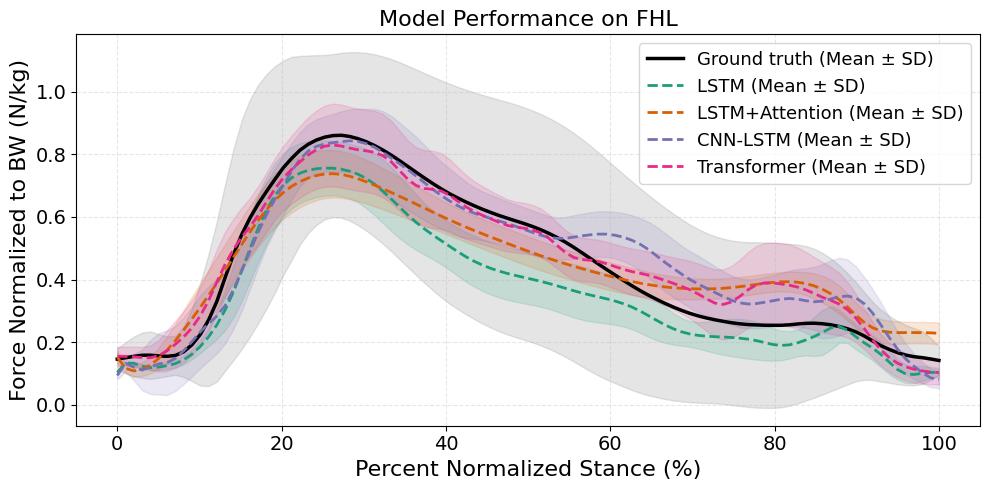

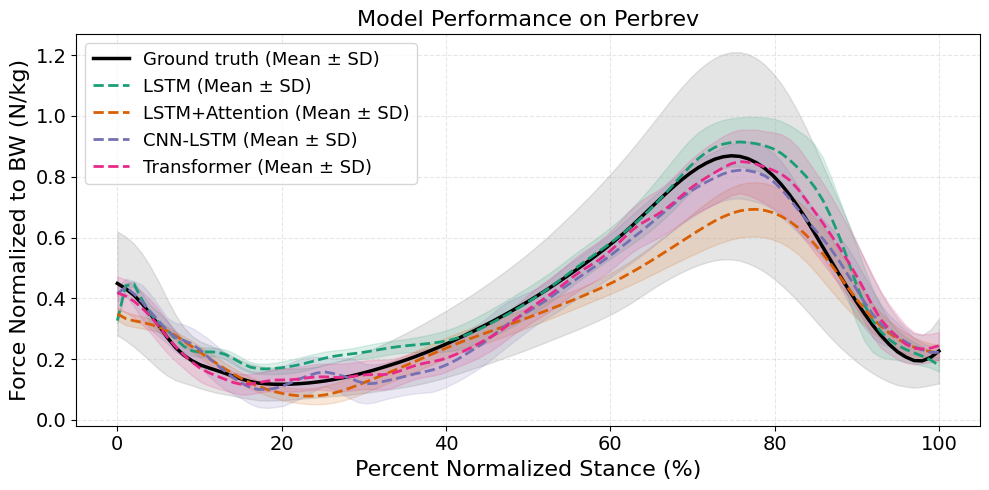

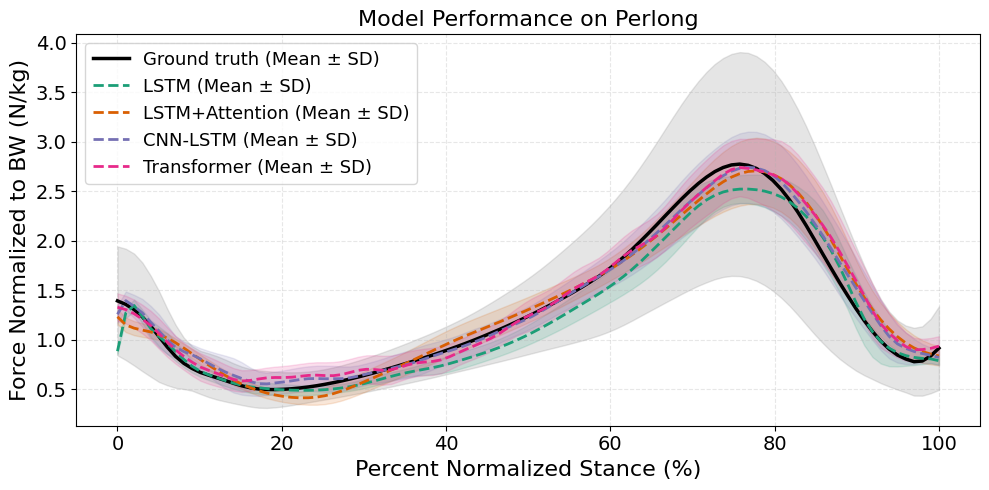

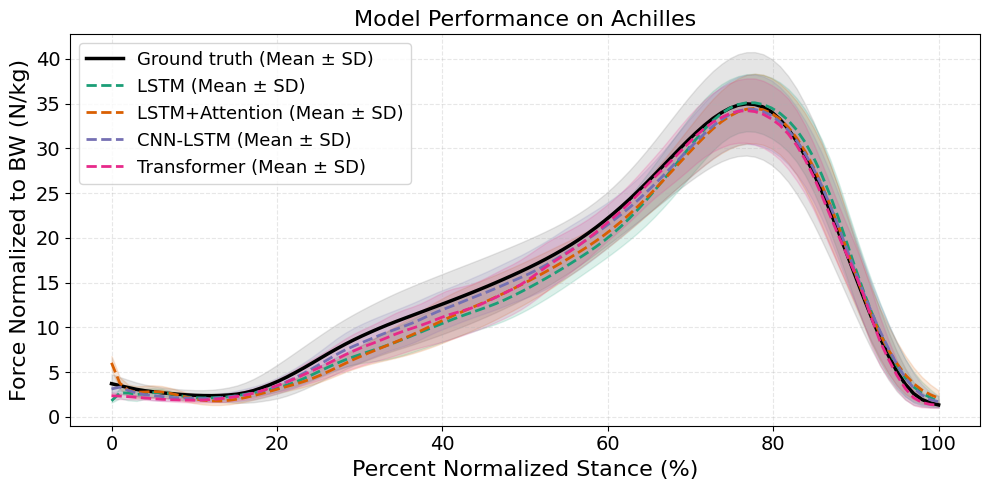

In [84]:
for i, lbl in enumerate(_eval_labels):
    true_m = y_eval[:, :, i].mean(axis=0)
    true_s = y_eval[:, :, i].std(axis=0)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(perc_stance, true_m, color='black', linewidth=2.5, label='Ground truth (Mean ± SD)')
    ax.fill_between(perc_stance, true_m - true_s, true_m + true_s, color='gray', alpha=0.2)

    for model_name, label, color in zip(MODELS_TO_COMPARE, MODEL_LABELS, MODEL_COLORS):
        if model_name not in preds_eval:
            continue
        pred_m = preds_eval[model_name][:, :, i].mean(axis=0)
        pred_s = preds_eval[model_name][:, :, i].std(axis=0)
        ax.plot(perc_stance, pred_m, color=color, linewidth=2, linestyle='--',
                label=f'{label} (Mean ± SD)')
        ax.fill_between(perc_stance, pred_m - pred_s, pred_m + pred_s, color=color, alpha=0.15)
    if lbl == 'ehl' or lbl == 'edl' or lbl == 'fdl' or lbl == 'fhl':
        lbl_string = str(lbl).upper()   
    else:
        lbl_string = str(lbl).capitalize()
    ax.set_title(f'Model Performance on {lbl_string}', fontsize=16)
    ax.set_xlabel('Percent Normalized Stance (%)', fontsize=16)
    ax.set_ylabel('Force Normalized to BW (N/kg)', fontsize=16)
    ax.legend(fontsize=13)
    ax.tick_params(labelsize=14)
    ax.grid(linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{lbl}.svg', format='svg')
    plt.show()

## Visualization — single test sample (SAMPLE_IDX)

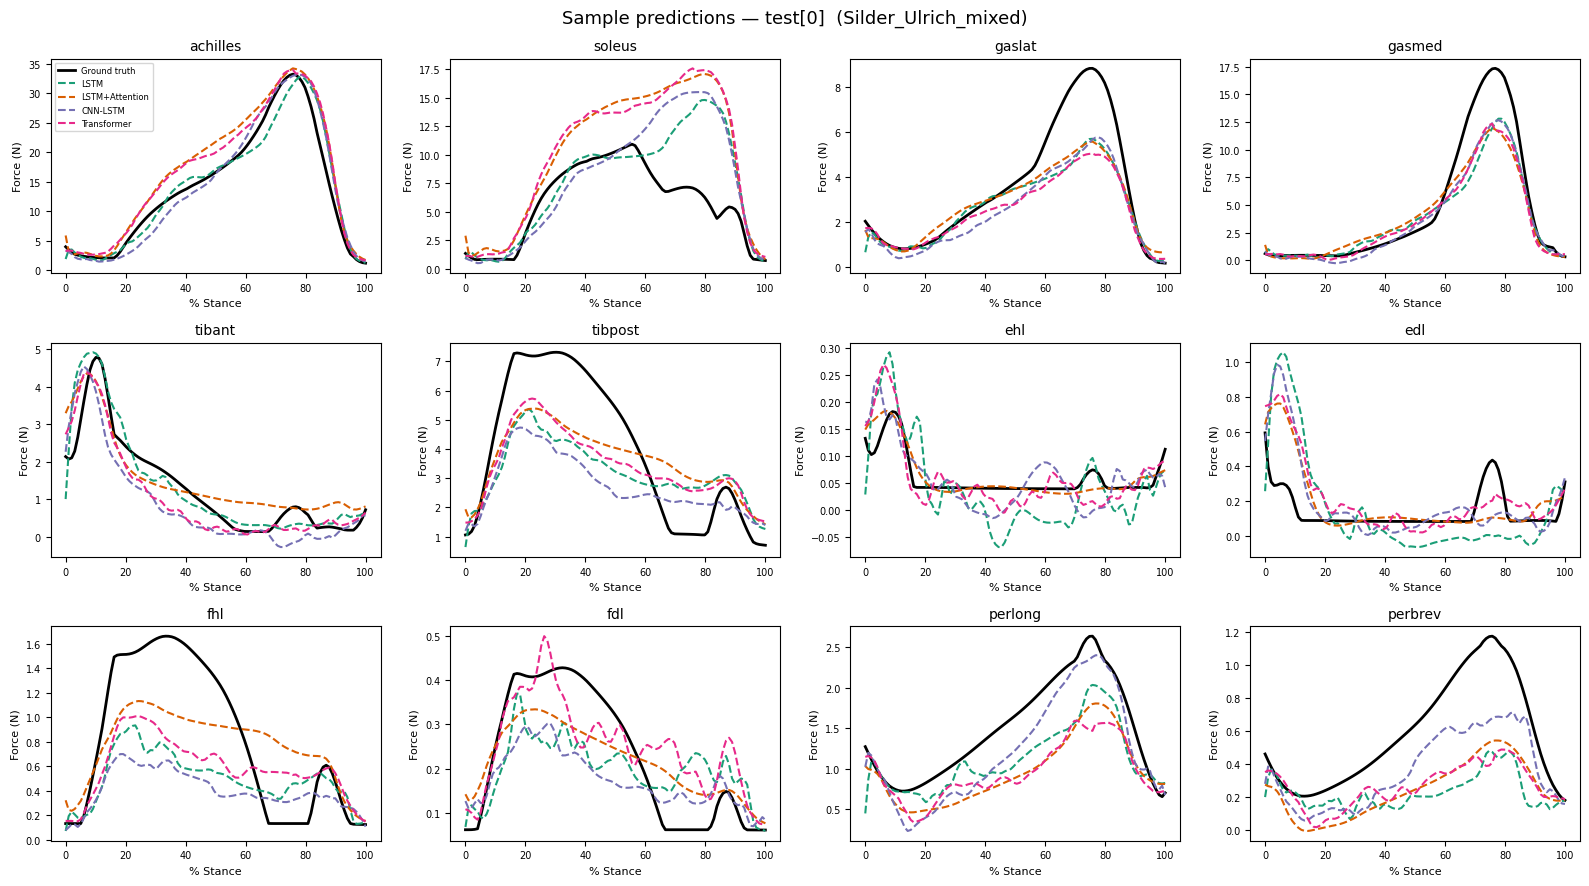

In [360]:
true_sample = y_eval[SAMPLE_IDX]   # (seq_len, N_EVAL)

ncols = 4
nrows = math.ceil(N_EVAL / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for i, lbl in enumerate(_eval_labels):
    ax = axes[i]
    ax.plot(perc_stance, true_sample[:, i], color='black', linewidth=2, label='Ground truth')
    for model_name, label, color in zip(MODELS_TO_COMPARE, MODEL_LABELS, MODEL_COLORS):
        if model_name not in preds_eval:
            continue
        ax.plot(perc_stance, preds_eval[model_name][SAMPLE_IDX, :, i],
                color=color, linewidth=1.5, linestyle='--', label=label)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel('% Stance', fontsize=8)
    ax.set_ylabel('Force (N)', fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=6)

for j in range(N_EVAL, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Sample predictions — test[{SAMPLE_IDX}]  ({output_prefix})', fontsize=13)
plt.tight_layout()
plt.show()

## Bar charts — per-output metrics

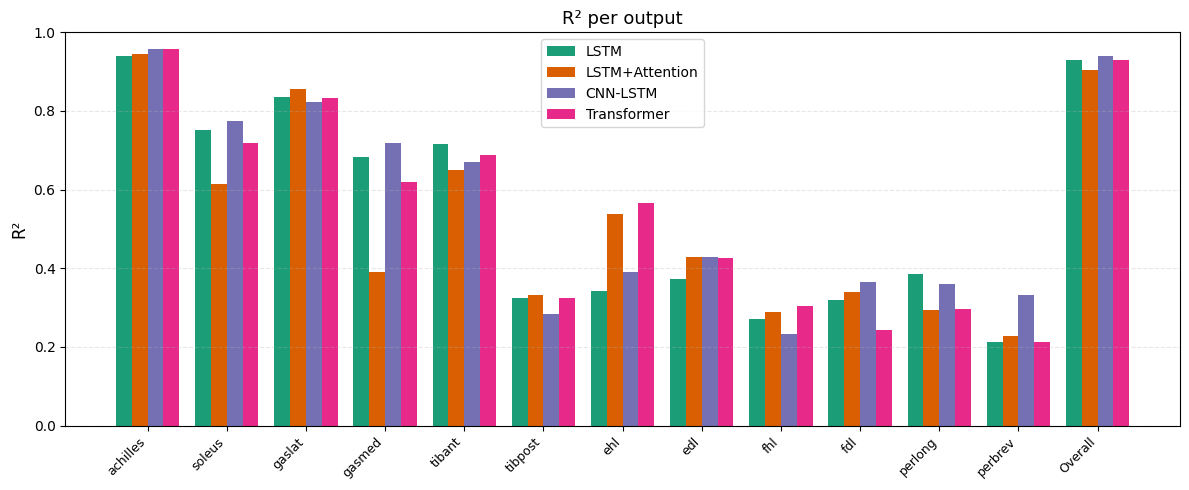

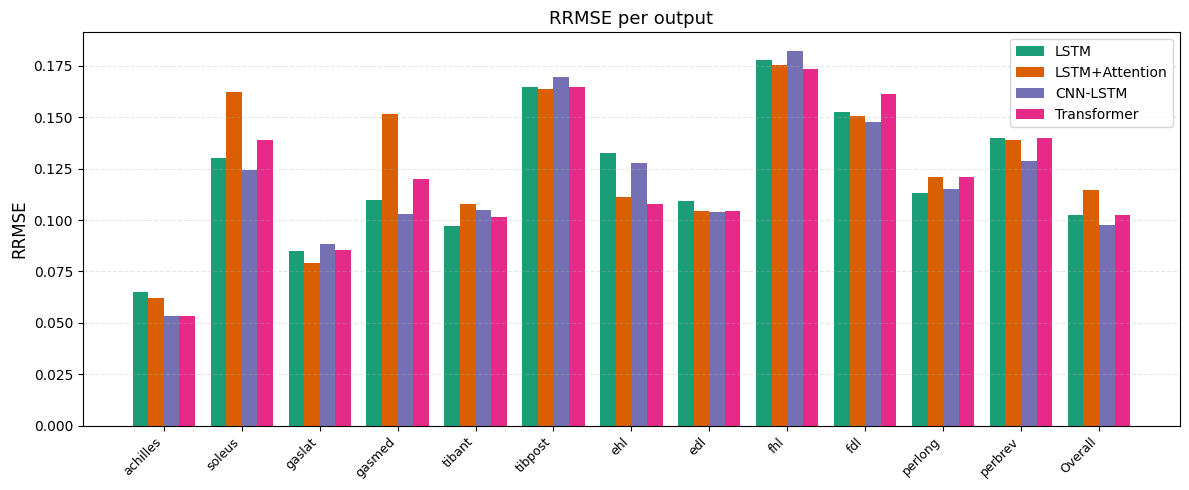

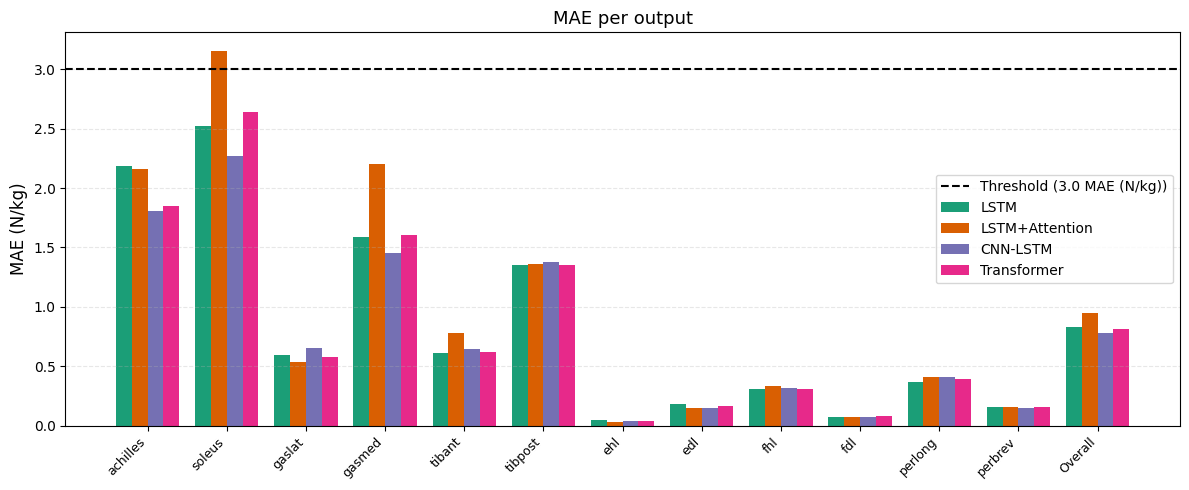

In [361]:
def _bar_chart(metric_key, ylabel, title, ylim=None, threshold=None, save_path=None):
    models_present = [n for n in MODELS_TO_COMPARE if n in per_output]
    labels_present = [MODEL_LABELS[MODELS_TO_COMPARE.index(n)] for n in models_present]
    colors_present = [MODEL_COLORS[MODELS_TO_COMPARE.index(n)] for n in models_present]

    vals_per_out = np.array([per_output[n][metric_key] for n in models_present])   # (m, N_EVAL)

    if metric_key == 'rrmse':
        vals_overall = np.array([overall[n]['rrmse_w'] for n in models_present])
    elif metric_key == 'mae':
        vals_overall = np.array([overall[n]['mae'] for n in models_present])
    else:
        vals_overall = np.array([overall[n]['r2'] for n in models_present])

    all_vals = np.hstack([vals_per_out, vals_overall.reshape(-1, 1)])  # (m, N_EVAL+1)
    x        = np.arange(N_EVAL + 1)
    bar_w    = 0.8 / len(models_present)
    offsets  = np.arange(len(models_present)) * bar_w - (len(models_present) - 1) * bar_w / 2

    fig, ax = plt.subplots(figsize=(max(12, N_EVAL * 0.9), 5))
    for label, color, offset, row in zip(labels_present, colors_present, offsets, all_vals):
        ax.bar(x + offset, row, width=bar_w, label=label, color=color)

    if threshold is not None:
        ax.axhline(threshold, color='black', linewidth=1.5, linestyle='--',
                   label=f'Threshold ({threshold} {ylabel})')

    ax.set_xticks(x)
    ax.set_xticklabels(list(_eval_labels) + ['Overall'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13)
    if ylim:
        ax.set_ylim(*ylim)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, format='svg')
    plt.show()


_bar_chart('r2',    'R²',         'R² per output',    ylim=(None, 1.0))
_bar_chart('rrmse', 'RRMSE',      'RRMSE per output')
_bar_chart('mae',   'MAE (N/kg)', 'MAE per output',
           threshold=3.0, save_path=f'{output_prefix}_mae_per_output.svg')

## LaTeX tables

In [200]:
def generate_latex_table(metric_key, caption=''):
    """Rows = outputs in _eval_labels, columns = models. Last row = overall."""
    models_present = [n for n in MODELS_TO_COMPARE if n in per_output]
    labels_present = [MODEL_LABELS[MODELS_TO_COMPARE.index(n)] for n in models_present]

    col_spec = 'l' + 'c' * len(models_present)
    header   = ' & '.join([f'\\textbf{{{lbl}}}' for lbl in labels_present])

    lines = [
        '\\begin{table}', '\\centering',
        f'\\begin{{tabular}}{{{col_spec}}}',
        '\\toprule',
        f'\\textbf{{Output}} & {header} \\\\',
        '\\midrule',
    ]

    for i, lbl in enumerate(_eval_labels):
        row = ' & '.join([f'{per_output[n][metric_key][i]:.4f}' for n in models_present])
        lines.append(f'{lbl} & {row} \\\\')

    lines.append('\\midrule')

    if metric_key == 'rrmse':
        ov = {n: overall[n]['rrmse_w'] for n in models_present}
    elif metric_key == 'mae':
        ov = {n: overall[n]['mae'] for n in models_present}
    else:
        ov = {n: overall[n]['r2'] for n in models_present}

    ov_row = ' & '.join([f'{ov[n]:.4f}' for n in models_present])
    lines.append(f'Overall & {ov_row} \\\\')
    lines += [
        '\\bottomrule',
        f'\\end{{tabular}}',
        f'\\caption{{{caption}}}',
        '\\label{tab:' + metric_key + '}',
        '\\end{table}',
    ]
    return '\n'.join(lines)


print('=== RRMSE table ===')
print(generate_latex_table('rrmse', caption='RRMSE per output across models.'))
print()
print('=== MAE table ===')
print(generate_latex_table('mae',   caption='MAE (N/kg) per output across models.'))
print()
print('=== R² table ===')
print(generate_latex_table('r2',    caption='R² per output across models.'))

=== RRMSE table ===
\begin{table}
\centering
\begin{tabular}{lcccc}
\toprule
\textbf{Output} & \textbf{LSTM} & \textbf{CNN-LSTM} & \textbf{LSTM+Attention} & \textbf{Transformer} \\
\midrule
achilles & 0.0648 & 0.0622 & 0.0533 & 0.0534 \\
gasmed & 0.1096 & 0.1516 & 0.1030 & 0.1199 \\
gaslat & 0.0850 & 0.0793 & 0.0882 & 0.0853 \\
soleus & 0.1303 & 0.1622 & 0.1243 & 0.1388 \\
tibant & 0.0970 & 0.1080 & 0.1047 & 0.1017 \\
tibpost & 0.1646 & 0.1638 & 0.1694 & 0.1647 \\
ehl & 0.1328 & 0.1114 & 0.1279 & 0.1079 \\
edl & 0.1092 & 0.1043 & 0.1042 & 0.1045 \\
fhl & 0.1778 & 0.1756 & 0.1822 & 0.1737 \\
fdl & 0.1528 & 0.1508 & 0.1476 & 0.1612 \\
perbrev & 0.1399 & 0.1387 & 0.1290 & 0.1401 \\
perlong & 0.1131 & 0.1211 & 0.1153 & 0.1209 \\
\midrule
Overall & 0.1025 & 0.1148 & 0.0975 & 0.1024 \\
\bottomrule
\end{tabular}
\caption{RRMSE per output across models.}
\label{tab:rrmse}
\end{table}

=== MAE table ===
\begin{table}
\centering
\begin{tabular}{lcccc}
\toprule
\textbf{Output} & \textbf{LSTM} & \